# EDA NOTEBOOK

## I. Introduction and Setup

### 1. Introduction

**Notebook này thực hiện Exploratory Data Analysis (EDA)** trên bộ dữ liệu 
[UCI Heart Disease Dataset] để hiểu sâu về cấu trúc dữ liệu
, phân phối của các đặc trưng, mối tương quan giữa các biến,
và các vấn đề cần xử lý trước khi xây dựng mô hình.

### 2. EDA Roadmap

| Bước | Nội dung | Người thực hiện |
|------|----------|-----------------|
| I | Introduction & Setup | Cả nhóm |
| II | Target Analysis | Quyên |
| III | Categorical Analysis | Quyên |
| IV | Distribution Analysis | Phát |
| V | Correlation Analysis | Phát |
| VI | Outlier Detection | Xuyên |
| VII | Statistical Tests | Xuyên |
| VIII | Key Findings | Cả nhóm |

### 3. Environment Setup and Library Import

In [5]:
#import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import numpy
import os


#hàm load data set để handle error và tái sử dụng
def load_dataset(dataset_path):
    """
    Kiểm tra và lấy dữ liệu từ file csv 
    Args:
        dataset_path (str): đường dẫn file csv 
    Returns:
        pandas.dataframe: bảng dữ liệu đã được đọc
    """
    if not os.path.exists(dataset_path):
        print("Không tìm thấy file!")
        return None
    
    try: 
        df = pd.read_csv(dataset_path)
        print("Đã tải dữ liệu thành công!")
        return df
    except Exception as e:
        print(f"Đã xảy ra lỗi trong quá trình tải: {e}")
        return None
    
#define dataset path
dataset_path = "../data/dataset.csv"

#load data
df = load_dataset(dataset_path=dataset_path)

Đã tải dữ liệu thành công!


### 4. Data Overview
Đây là tập dữ liệu thô được lấy từ nguồn **[UCI Heart Disease Dataset]**
Link: https://archive.ics.uci.edu/dataset/45/heart+disease

In [6]:
#Hiển thị tổng quan về các thông tin của dataset: số hàng, số cột, kiểu dữ liệu, số giá trị non-null mỗi cột, ...
print("Tổng quan cấu trúc dataset:")

#Thông tin số dòng số cột
print(f"- Dataset có {df.shape[0]} dòng và {df.shape[1]} cột.")

Tổng quan cấu trúc dataset:
- Dataset có 920 dòng và 16 cột.


In [7]:
#Thông tin kiểu dữ liệu từng cột, số giá trị non-null
print("- Các thông tin cơ bản:")
df.info()

- Các thông tin cơ bản:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [8]:
#Thông tin về trung bình, độ lệch chuẩn, tứ phân vị, giá trị nhỏ nhất lớn nhất
print("- Các thông tin thống kê:")
df.describe()

- Các thông tin thống kê:


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [9]:
#5 hàng dữ liệu đầu tiên
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


II. Exploratory Data Analysis (EDA)

    5.Outlier-Analysis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina    

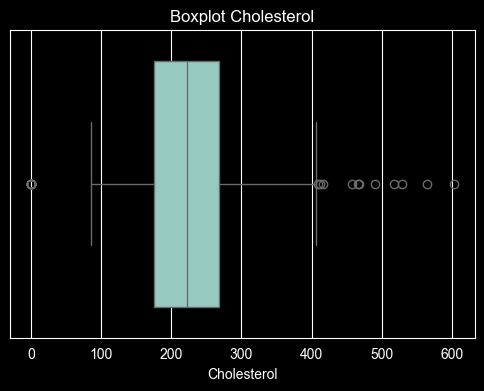

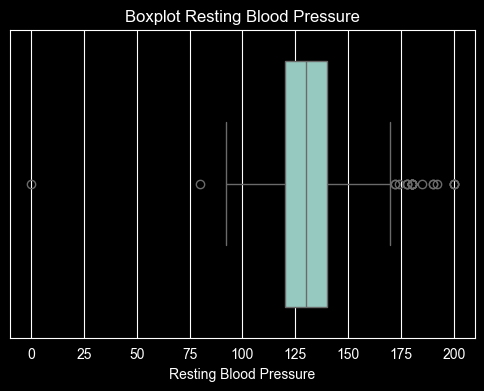


===== Outlier Cholesterol =====
Lower bound: 35.5
Upper bound: 407.5
Số lượng outlier: 183

===== Outlier Blood Pressure =====
Lower bound: 90.0
Upper bound: 170.0
Số lượng outlier: 28

===== T-Test Age =====
T-statistic: 8.929630433627022
P-value: 2.2906138697114922e-18

===== Kết luận =====
Bác bỏ H0
→ Tuổi có ảnh hưởng đến nguy cơ bệnh tim


In [11]:
#kiem tra dữ liệu
if df is not None:
    print(df.info())
    print(df.head())
    print(df.describe())

# vẽ boxplot cholesterol
plt.figure(figsize=(6,4))

seaborn.boxplot(x=df["chol"])

plt.title("Boxplot Cholesterol")
plt.xlabel("Cholesterol")

plt.show()

#BoxplotHuyetáp (trestbps)
plt.figure(figsize=(6,4))

seaborn.boxplot(x=df["trestbps"])

plt.title("Boxplot Resting Blood Pressure")
plt.xlabel("Resting Blood Pressure")

plt.show()

#Phát hiện Outlier Cholesterol (IQR)
Q1 = df["chol"].quantile(0.25)
Q3 = df["chol"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_chol = df[(df["chol"] < lower_bound) | (df["chol"] > upper_bound)]

print("\n===== Outlier Cholesterol =====")
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Số lượng outlier:", len(outliers_chol))

#Phát hiện Outlier Huyết áp
Q1_bp = df["trestbps"].quantile(0.25)
Q3_bp = df["trestbps"].quantile(0.75)

IQR_bp = Q3_bp - Q1_bp

lower_bp = Q1_bp - 1.5 * IQR_bp
upper_bp = Q3_bp + 1.5 * IQR_bp

outliers_bp = df[(df["trestbps"] < lower_bp) | (df["trestbps"] > upper_bp)]

print("\n===== Outlier Blood Pressure =====")
print("Lower bound:", lower_bp)
print("Upper bound:", upper_bp)
print("Số lượng outlier:", len(outliers_bp))

#Chuẩn hóa nhãn bệnh tim
df["disease"] = df["num"].apply(lambda x: 1 if x > 0 else 0)

#T-test kiểm định tuổi
from scipy import stats

group_disease = df[df["disease"] == 1]["age"]
group_no_disease = df[df["disease"] == 0]["age"]

t_stat, p_value = stats.ttest_ind(group_disease, group_no_disease)

print("\n===== T-Test Age =====")
print("T-statistic:", t_stat)
print("P-value:", p_value)

#Kết luận thống kê
alpha = 0.05

print("\n===== Kết luận =====")

if p_value < alpha:
    print("Bác bỏ H0")
    print("→ Tuổi có ảnh hưởng đến nguy cơ bệnh tim")
else:
    print("Không đủ bằng chứng bác bỏ H0")

    2.  